In [1]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec

sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset to inspect its size and structure
train = pd.read_csv("train.tsv.gz", sep="\t", compression="gzip")

print("Dataset shape:", train.shape)
train.head()

Dataset shape: (12709329, 2)


,id,clicks
0,1,"2298389,5781785"
1,5,"2062628,3754661,7076564,6024981"
2,6,"3961480,6473398,3598595,1705547,4762815,631488..."
3,7,"1759325,533139,7140337"
4,15,"2529376,4444475,7649335,2183536"


In [3]:
# Inspect dataset structure and check for missing values
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12709329 entries, 0 to 12709328
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   clicks  object
dtypes: int64(1), object(1)
memory usage: 193.9+ MB


id        0
clicks    0
dtype: int64

In [4]:
# Generate summary statistics for all columns to understand the dataset distribution
train.describe(include="all")

,id,clicks
count,1.270933e+07,12709329
unique,NaN,11671937
top,NaN,"5349766,4692612"
freq,NaN,596
mean,8.549127e+11,NaN
std,4.958974e+11,NaN
min,1.000000e+00,NaN
25%,4.294967e+11,NaN
50%,8.589935e+11,NaN
75%,1.288490e+12,NaN


In [5]:
# Convert the clicks column into hotel session lists and compute the number of hotels per session
train["session"] = train["clicks"].apply(lambda x: [h.strip() for h in str(x).split(",") if h.strip()])
train["session_length"] = train["session"].apply(len)

train[["id", "session", "session_length"]].head()

,id,session,session_length
0,1,"[2298389, 5781785]",2
1,5,"[2062628, 3754661, 7076564, 6024981]",4
2,6,"[3961480, 6473398, 3598595, 1705547, 4762815, ...",18
3,7,"[1759325, 533139, 7140337]",3
4,15,"[2529376, 4444475, 7649335, 2183536]",4


In [6]:
# Compute overall dataset statistics such as total sessions, total clicks, unique hotels, and session length metrics
all_hotels = [hotel for session in train["session"] for hotel in session]
unique_hotels = set(all_hotels)

print("Total sessions:", len(train))
print("Total clicked hotel events:", len(all_hotels))
print("Unique hotels:", len(unique_hotels))
print("Average session length:", train["session_length"].mean())
print("Median session length:", train["session_length"].median())
print("Min session length:", train["session_length"].min())
print("Max session length:", train["session_length"].max())

Total sessions: 12709329
Total clicked hotel events: 79102862
Unique hotels: 1166727
Average session length: 6.223999866554718
Median session length: 3.0
Min session length: 2
Max session length: 200


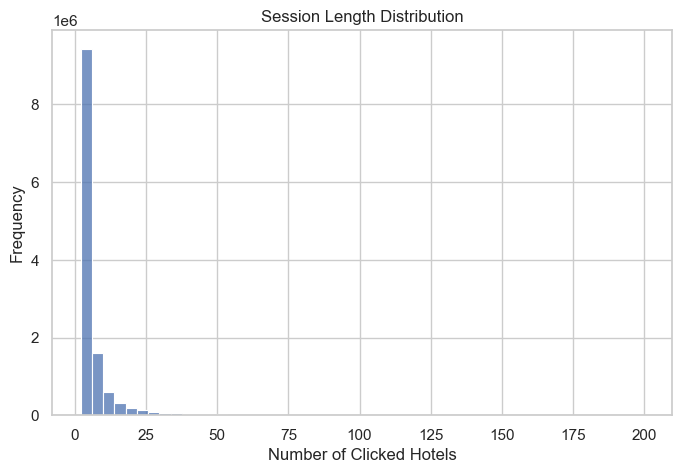

In [7]:
# Plot the distribution of session lengths to understand how many hotels users typically click per session
plt.figure(figsize=(8,5))
sns.histplot(train["session_length"], bins=50)

plt.title("Session Length Distribution")
plt.xlabel("Number of Clicked Hotels")
plt.ylabel("Frequency")

plt.show()

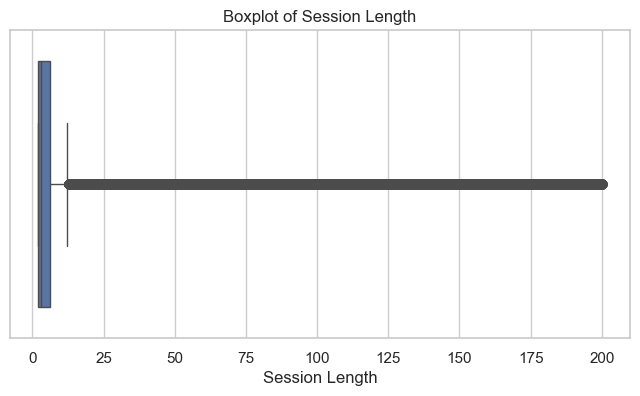

In [8]:
# Visualize the distribution and potential outliers of session lengths using a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=train["session_length"])
plt.title("Boxplot of Session Length")
plt.xlabel("Session Length")
plt.show()

In [9]:
# Calculate key percentiles of session length to understand the distribution of user session sizes
print(train["session_length"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

0.25     2.0
0.50     3.0
0.75     6.0
0.90    12.0
0.95    20.0
0.99    56.0
Name: session_length, dtype: float64


In [10]:
# Generate descriptive statistics for session lengths to summarize user interaction behavior
train["session_length"].describe()

count    1.270933e+07
mean     6.224000e+00
std      1.088734e+01
min      2.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      2.000000e+02
Name: session_length, dtype: float64

In [11]:
# Compute basic dataset statistics such as total sessions, average session length, maximum session length, and number of unique hotels
all_hotels = [hotel for session in train["session"] for hotel in session]

print("Total sessions:", len(train))
print("Average session length:", train["session_length"].mean())
print("Max session length:", train["session_length"].max())
print("Unique hotels:", len(set(all_hotels)))

Total sessions: 12709329
Average session length: 6.223999866554718
Max session length: 200
Unique hotels: 1166727


In [12]:
# Identify and visualize the top 20 most frequently clicked hotels in the dataset
hotel_counts = Counter(all_hotels)
top_hotels = hotel_counts.most_common(20)

top_hotels_df = pd.DataFrame(top_hotels, columns=["hotel_id", "click_count"])
top_hotels_df

,hotel_id,click_count
0,6992713,29003
1,5349766,27833
2,81741,26280
3,1520952,26089
4,4095166,25185
5,2306952,25004
6,1734369,25000
7,6039019,23068
8,3350243,22481
9,5795906,21966


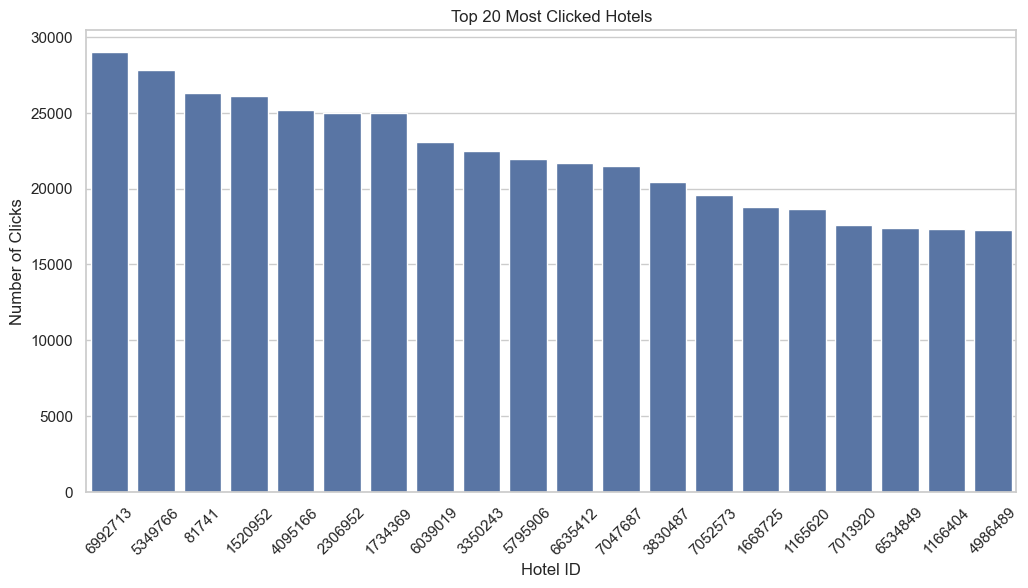

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_hotels_df, x="hotel_id", y="click_count")
plt.title("Top 20 Most Clicked Hotels")
plt.xlabel("Hotel ID")
plt.ylabel("Number of Clicks")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Analyze and visualize the long-tail distribution of hotel popularity based on click frequency
hotel_counts = Counter(all_hotels)

counts = sorted(hotel_counts.values(), reverse=True)
top_hotels = hotel_counts.most_common(10)
top_hotels

[('6992713', 29003),
 ('5349766', 27833),
 ('81741', 26280),
 ('1520952', 26089),
 ('4095166', 25185),
 ('2306952', 25004),
 ('1734369', 25000),
 ('6039019', 23068),
 ('3350243', 22481),
 ('5795906', 21966)]

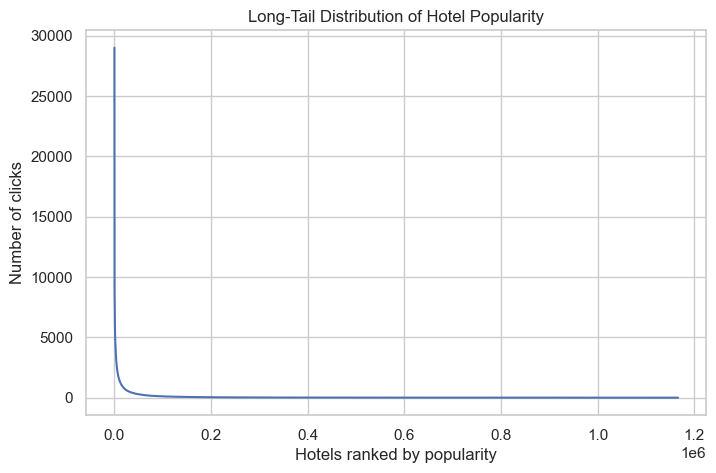

In [15]:
plt.figure(figsize=(8,5))
plt.plot(counts)

plt.title("Long-Tail Distribution of Hotel Popularity")
plt.xlabel("Hotels ranked by popularity")
plt.ylabel("Number of clicks")

plt.show()

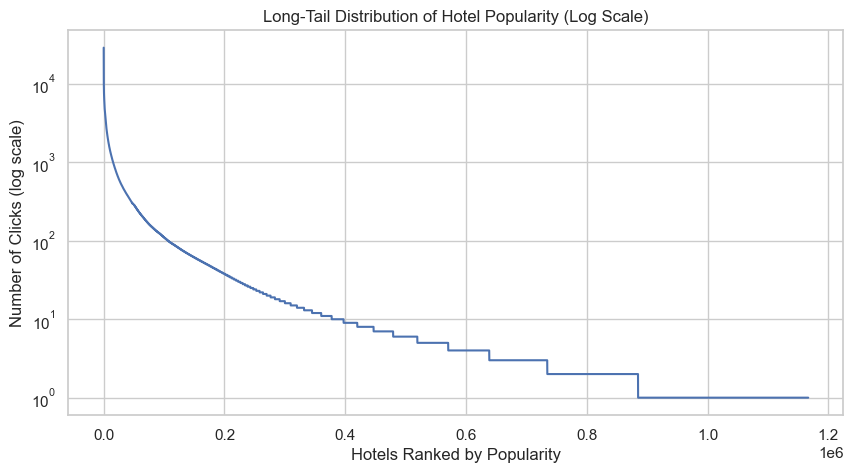

In [16]:
# Visualize the long-tail distribution of hotel popularity using a logarithmic scale to highlight differences in click frequency
plt.figure(figsize=(10, 5))
plt.plot(counts)
plt.yscale("log")
plt.title("Long-Tail Distribution of Hotel Popularity (Log Scale)")
plt.xlabel("Hotels Ranked by Popularity")
plt.ylabel("Number of Clicks (log scale)")
plt.show()

In [17]:
# Analyze and visualize how frequently different session lengths occur in the dataset
session_freq = train["session_length"].value_counts().sort_index()
session_freq.head(20)

session_length
2     4881079
3     2352342
4     1340147
5      863980
6      594303
7      430205
8      322847
9      248652
10     197154
11     158381
12     130789
13     109161
14      92377
15      80104
16      70021
17      61113
18      54264
19      48394
20      43712
21      39327
Name: count, dtype: int64

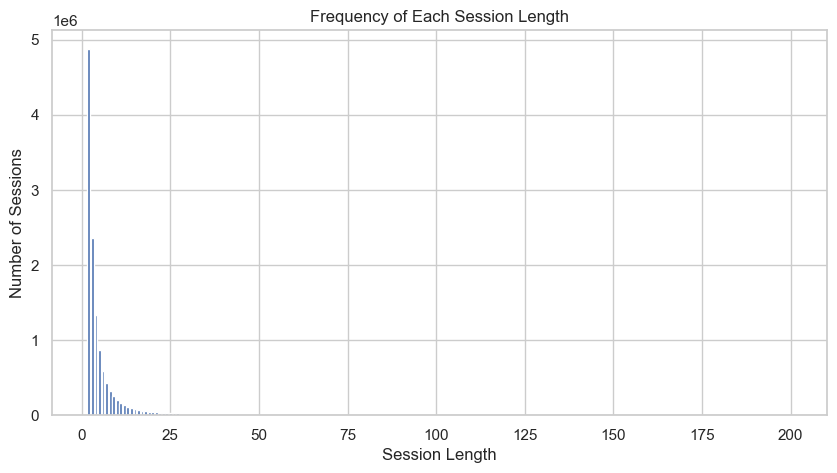

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(session_freq.index, session_freq.values)
plt.title("Frequency of Each Session Length")
plt.xlabel("Session Length")
plt.ylabel("Number of Sessions")
plt.show()

In [19]:
# Calculate how many sessions contain only one click versus multiple clicks to understand user interaction patterns
single_click_sessions = (train["session_length"] == 1).sum()
multi_click_sessions = (train["session_length"] >= 2).sum()

print("Sessions with 1 click:", single_click_sessions)
print("Sessions with 2+ clicks:", multi_click_sessions)
print("Percentage with 1 click:", single_click_sessions / len(train))

Sessions with 1 click: 0
Sessions with 2+ clicks: 12709329
Percentage with 1 click: 0.0


In [ ]:
# In this dataset, the minimum session length is already 2.
# Filter out sessions with only one click, analyze the cleaned data distribution, and take a 5% sample for modeling
train = train[train["session_length"] >= 2].copy()

# Analysis after filtering
print("Filtered dataset shape:", train.shape)
print("Average session length:", train["session_length"].mean())

Filtered dataset shape: (12709329, 4)
Average session length: 6.223999866554718


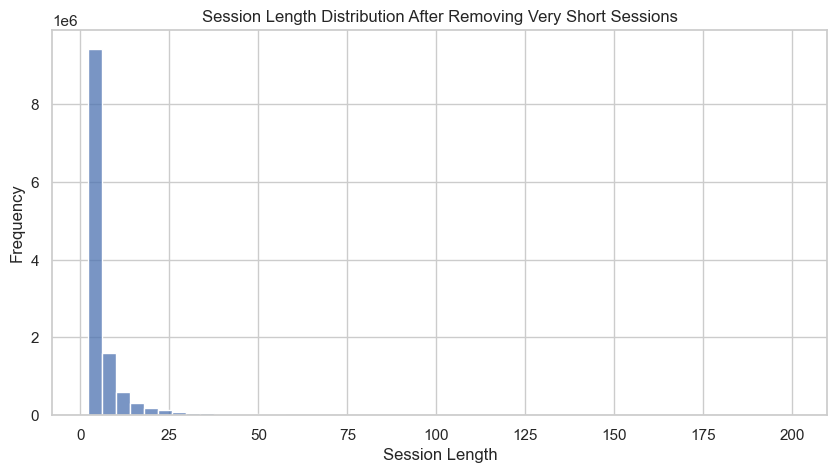

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(train["session_length"], bins=50)
plt.title("Session Length Distribution After Removing Very Short Sessions")
plt.xlabel("Session Length")
plt.ylabel("Frequency")
plt.show()

In [22]:
# Take 5% sample
sample_df = train.sample(frac=0.05, random_state=42)

print("Sample size:", sample_df.shape)

Sample size: (635466, 4)


In [23]:
# Compare the session length statistics between the original dataset and the sampled dataset
print("Original avg session length:", train["session_length"].mean())
print("Sample avg session length:", sample_df["session_length"].mean())

print("Original median session length:", train["session_length"].median())
print("Sample median session length:", sample_df["session_length"].median())

Original avg session length: 6.223999866554718
Sample avg session length: 6.225041150903431
Original median session length: 3.0
Sample median session length: 3.0


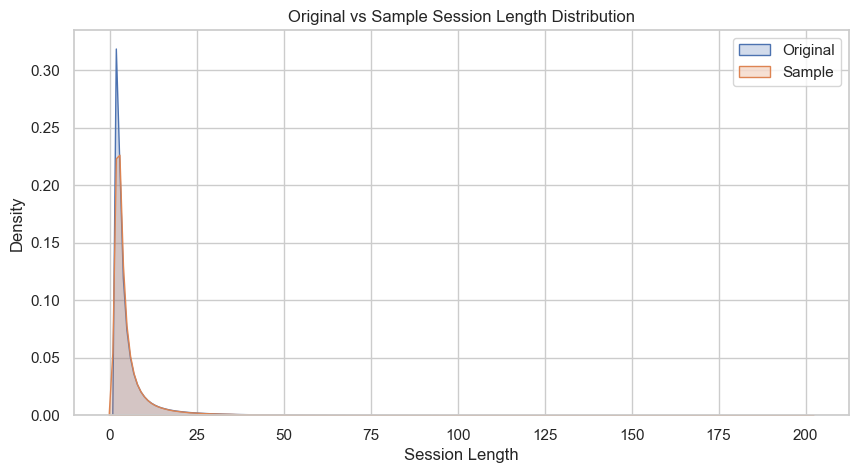

In [24]:
# Visualize and compare the session length distributions between the original dataset and the sampled dataset
plt.figure(figsize=(10, 5))
sns.kdeplot(train["session_length"], label="Original", fill=True)
sns.kdeplot(sample_df["session_length"], label="Sample", fill=True)
plt.title("Original vs Sample Session Length Distribution")
plt.xlabel("Session Length")
plt.ylabel("Density")
plt.legend()
plt.show()

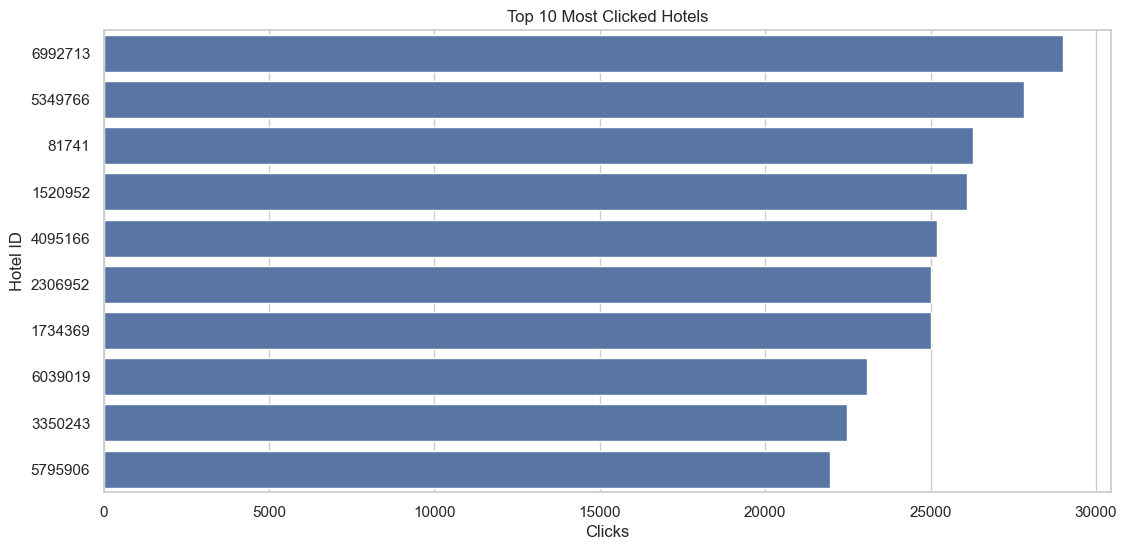

In [25]:
# Visualize the top 10 most frequently clicked hotels to analyze popularity patterns
hotels, counts = zip(*top_hotels)

plt.figure(figsize=(13,6))
sns.barplot(y=list(hotels), x=list(counts))
plt.title("Top 10 Most Clicked Hotels")
plt.xlabel("Clicks")
plt.ylabel("Hotel ID")
plt.show()

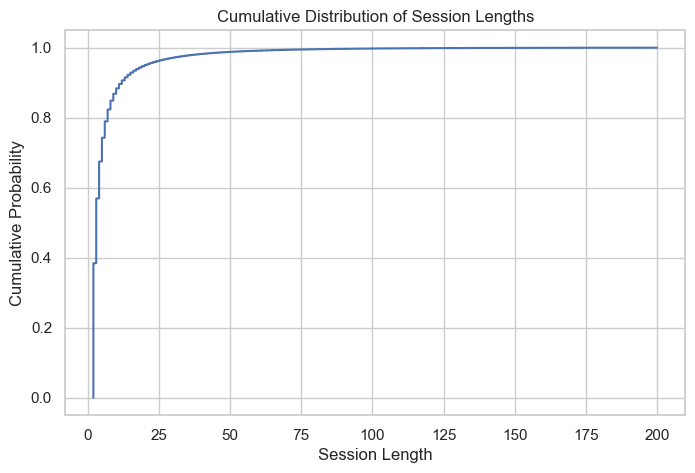

In [30]:
# Cumulative distribution of session lengths
sorted_lengths = np.sort(train["session_length"])
cum_probs = np.arange(1, len(sorted_lengths)+1) / len(sorted_lengths)

plt.figure(figsize=(8,5))
plt.plot(sorted_lengths, cum_probs)

plt.title("Cumulative Distribution of Session Lengths")
plt.xlabel("Session Length")
plt.ylabel("Cumulative Probability")

plt.show()

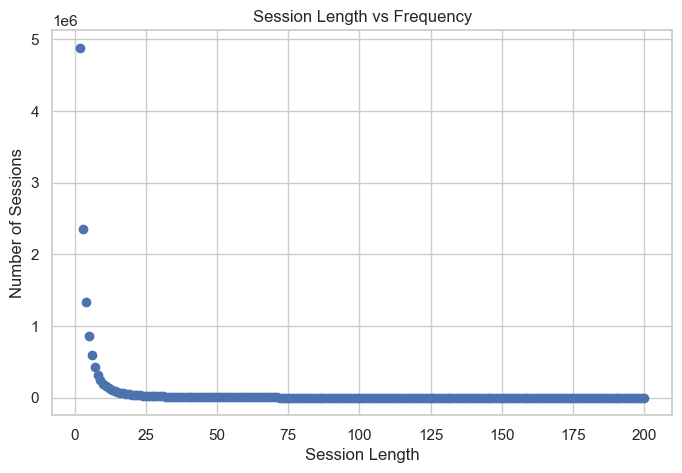

In [31]:
# Scatter plot of session length frequency
session_freq = train["session_length"].value_counts()

plt.figure(figsize=(8,5))
plt.scatter(session_freq.index, session_freq.values)

plt.title("Session Length vs Frequency")
plt.xlabel("Session Length")
plt.ylabel("Number of Sessions")

plt.show()

In [32]:
# Split the sampled dataset into training (80%), evaluation (10%), and test (10%) sets
train_data, temp_data = train_test_split(
    sample_df,
    test_size=0.2,
    random_state=42
)

eval_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42
)

In [33]:
# Verify the sizes and ratios of the train, evaluation, and test splits
print("Train size:", train_data.shape)
print("Evaluation size:", eval_data.shape)
print("Test size:", test_data.shape)

total = len(sample_df)
print("Train ratio:", len(train_data) / total)
print("Evaluation ratio:", len(eval_data) / total)
print("Test ratio:", len(test_data) / total)

Train size: (508372, 4)
Evaluation size: (63547, 4)
Test size: (63547, 4)
Train ratio: 0.7999987410813482
Evaluation ratio: 0.10000062945932592
Test ratio: 0.10000062945932592


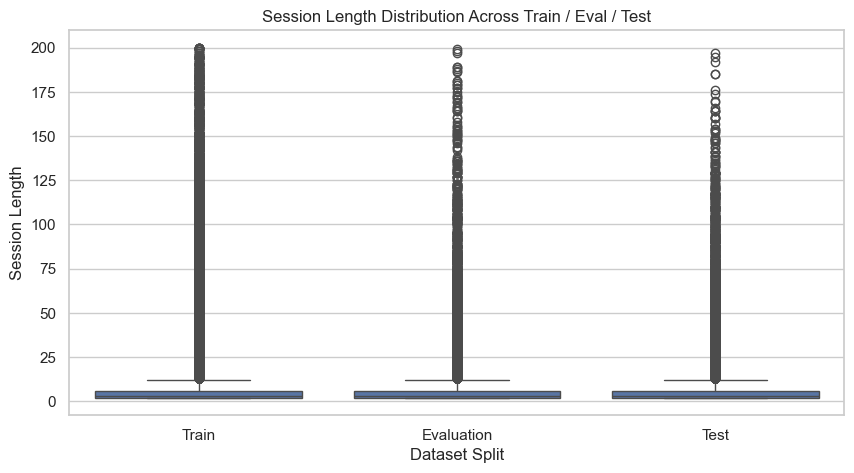

In [34]:
# Compare the session length distributions across the train, evaluation, and test datasets
split_plot_df = pd.concat([
    train_data[["session_length"]].assign(split="Train"),
    eval_data[["session_length"]].assign(split="Evaluation"),
    test_data[["session_length"]].assign(split="Test")
])

plt.figure(figsize=(10, 5))
sns.boxplot(data=split_plot_df, x="split", y="session_length")
plt.title("Session Length Distribution Across Train / Eval / Test")
plt.xlabel("Dataset Split")
plt.ylabel("Session Length")
plt.show()

In [35]:
# Create a summary table comparing dataset size and session length statistics across train, evaluation, and test splits
summary_df = pd.DataFrame({
    "split": ["train", "evaluation", "test"],
    "rows": [len(train_data), len(eval_data), len(test_data)],
    "avg_session_length": [
        train_data["session_length"].mean(),
        eval_data["session_length"].mean(),
        test_data["session_length"].mean()
    ],
    "median_session_length": [
        train_data["session_length"].median(),
        eval_data["session_length"].median(),
        test_data["session_length"].median()
    ]
})

summary_df

,split,rows,avg_session_length,median_session_length
0,train,508372,6.239767,3.0
1,evaluation,63547,6.171228,3.0
2,test,63547,6.161046,3.0


In [36]:
# Convert the train, evaluation, and test datasets into lists of sessions for sequence-based modeling
train_sessions = train_data["session"].tolist()
eval_sessions = eval_data["session"].tolist()
test_sessions = test_data["session"].tolist()

print("Example session:", train_sessions[0])
print("Example eval session:", eval_sessions[0])
print("Example test session:", test_sessions[0])

Example session: ['2775313', '5718478', '3197074', '2589288']
Example eval session: ['4819573', '6884188', '3416836', '4819573', '6884188']
Example test session: ['1486104', '6540492']


In [37]:
# Display the number of rows and columns for the train, evaluation, and test datasets
print("Train size:", train_data.shape)
print("Evaluation size:", eval_data.shape)
print("Test size:", test_data.shape)

print(eval_sessions[:3])
print(test_sessions[:3])

Train size: (508372, 4)
Evaluation size: (63547, 4)
Test size: (63547, 4)
[['4819573', '6884188', '3416836', '4819573', '6884188'], ['2769992', '5708686', '5446025', '5708686'], ['929296', '4122672']]
[['1486104', '6540492'], ['3540906', '288075', '6929285', '3844776', '2387812'], ['3581605', '6881166']]


In [38]:
#Save the train, evaluation, and test datasets as CSV files for later use
train_data.to_csv("train_sessions.csv", index=False)
eval_data.to_csv("eval_sessions.csv", index=False)
test_data.to_csv("test_sessions.csv", index=False)

In [ ]:
# Train Word2Vec model and extract embeddings

def train_w2v(
    train_data,
    vector_size=32,
    window=3,
    negative=8,
    alpha=0.001,
    sg=1,
    epochs=10,
    min_count=5,
    workers=4,
    seed=42
):
    return Word2Vec(
        sentences=train_data,
        vector_size=vector_size,
        window=window,
        negative=negative,
        alpha=alpha,
        sg=sg,
        min_count=min_count,
        workers=workers,
        epochs=epochs,
        seed=seed
    )

def export_embeddings(model):
    vocab = list(model.wv.index_to_key)
    hotel_to_idx = {hotel: i for i, hotel in enumerate(vocab)}
    idx_to_hotel = {i: hotel for hotel, i in hotel_to_idx.items()}
    W = model.wv.vectors.copy()
    #print("Embedding matrix shape:", W.shape)
    return W, hotel_to_idx, idx_to_hotel

In [ ]:
# Build popularity baseline and evaluate with Hits@K

def build_popular_baseline(train_sessions):
    counts = Counter()
    for session in train_sessions:
        counts.update(session)
    return [hotel for hotel, _ in counts.most_common()]

def hits_at_k_popular(data, popular_hotels, k=10):
    hits = 0
    total = 0

    for session in data:
        if len(session) < 2:
            continue

        seen = set(session[:-1])
        true_hotel = session[-1]

        #recs = [h for h in popular_hotels if h not in seen][:k]
        recs = []
        for h in popular_hotels:
            if h not in seen:
                recs.append(h)
            if len(recs) == k:
                break

        if true_hotel in recs:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0.0

In [ ]:
# Recommend using previous hotel (last interaction)

def recommend_next_hotels(prev_hotel, W, hotel_to_idx, idx_to_hotel, topk=10):
    if prev_hotel not in hotel_to_idx:
        return []

    h = W[hotel_to_idx[prev_hotel]]
    scores = h @ W.T
    scores[hotel_to_idx[prev_hotel]] = -np.inf

    top_indices = np.argsort(scores)[::-1][:topk]
    return [(idx_to_hotel[i], scores[i]) for i in top_indices]

def hits_at_k_prev(data, W, hotel_to_idx, idx_to_hotel, k=10):
    hits = 0
    total = 0
    skipped = 0

    for session in data:
        if len(session) < 2:
            skipped += 1
            continue

        prev_hotel = session[-2]
        true_hotel = session[-1]

        if prev_hotel not in hotel_to_idx or true_hotel not in hotel_to_idx:
            skipped += 1
            continue

        recs = recommend_next_hotels(prev_hotel, W, hotel_to_idx, idx_to_hotel, topk=k)
        rec_hotels = [hotel for hotel, _ in recs]

        if true_hotel in rec_hotels:
            hits += 1

        total += 1

    score = hits / total if total > 0 else 0.0
    
    return score, total, skipped

In [ ]:
# Recommend using full session context

def recommend_from_context(context_hotels, W, hotel_to_idx, idx_to_hotel, topk=10):
    context_vecs = [W[hotel_to_idx[h]] for h in context_hotels if h in hotel_to_idx]
    if not context_vecs:
        return []

    h = np.mean(context_vecs, axis=0)
    scores = h @ W.T

    for h_id in context_hotels:
        if h_id in hotel_to_idx:
            scores[hotel_to_idx[h_id]] = -np.inf

    top_indices = np.argsort(scores)[::-1][:topk]
    return [(idx_to_hotel[i], scores[i]) for i in top_indices]

def hits_at_k_context(data, W, hotel_to_idx, idx_to_hotel, k=10):
    hits = 0
    total = 0
    skipped = 0

    for session in data:
        if len(session) < 2:
            skipped += 1
            continue

        context = session[:-1]
        true_hotel = session[-1]

        if true_hotel not in hotel_to_idx:
            skipped += 1
            continue

        recs = recommend_from_context(context, W, hotel_to_idx, idx_to_hotel, topk=k)
        rec_hotels = [hotel for hotel, _ in recs]

        if true_hotel in rec_hotels:
            hits += 1

        total += 1

    score = hits / total if total > 0 else 0.0

    return score, total, skipped

In [62]:
# Train model and compare baseline vs embedding models

model = train_w2v(train_sessions)


W, hotel_to_idx, idx_to_hotel = export_embeddings(model)

popular_hotels = build_popular_baseline(train_sessions)
print("Top 10 most popular hotels:")
print(popular_hotels[:10])

popular_eval_hit10 = hits_at_k_popular(eval_sessions, popular_hotels, k=10)

prev_eval_hit10, prev_eval_total, prev_eval_skipped = hits_at_k_prev(
    eval_sessions, W, hotel_to_idx, idx_to_hotel, k=10
)
context_eval_hit10, context_eval_total, context_eval_skipped = hits_at_k_context(
    eval_sessions, W, hotel_to_idx, idx_to_hotel, k=10
)

print(f"Most Popular Eval Hits@10: {popular_eval_hit10:.4f}")
print(f"Prev Eval Hits@10: {prev_eval_hit10:.4f} | total={prev_eval_total} skipped={prev_eval_skipped}")
print(f"Context Eval Hits@10: {context_eval_hit10:.4f} | total={context_eval_total} skipped={context_eval_skipped}")


Top 10 most popular hotels:
['6992713', '5349766', '81741', '1520952', '2306952', '1734369', '4095166', '3350243', '5795906', '6039019']
Most Popular Eval Hits@10: 0.0035
Prev Eval Hits@10: 0.0072 | total=42353 skipped=21194
Context Eval Hits@10: 0.0053 | total=48824 skipped=14723


In [61]:
# Example recommendations for the previous-hotel model
example_hotel = train_sessions[0][-2]

print("\nExample previous hotel:")
print(example_hotel)

print("\nTop-5 recommendations:")
print(recommend_next_hotels(example_hotel, W, hotel_to_idx, idx_to_hotel, topk=5))

print(f"\nPrev Eval Hits@10: {prev_eval_hit10:.4f}")
print(f"Evaluated sessions: {prev_eval_total}")
print(f"Skipped sessions: {prev_eval_skipped}")


Example previous hotel:
3197074

Top-5 recommendations:
[('6992713', np.float32(0.007942258)), ('6382720', np.float32(0.0067773545)), ('3825215', np.float32(0.0064390004)), ('7521146', np.float32(0.006155723)), ('1519196', np.float32(0.0061343564))]

Prev Eval Hits@10: 0.0073
Evaluated sessions: 42353
Skipped sessions: 21194


In [ ]:
# Example of context-based recommendations

example_context = train_sessions[0][:-1]

print("\nExample session context:")
print(example_context)

print("\nTop-5 recommendations:")
print(recommend_from_context(example_context, W, hotel_to_idx, idx_to_hotel, topk=5))

print(f"\nContext Eval Hits@10: {context_eval_hit10:.4f}")
print(f"Evaluated sessions: {context_eval_total}")
print(f"Skipped sessions: {context_eval_skipped}")


Example session context:
['2775313', '5718478', '3197074']

Top-5 recommendations:
[('3350243', np.float32(0.0053779827)), ('6992713', np.float32(0.0051447214)), ('4095166', np.float32(0.004632936)), ('2361582', np.float32(0.00439558)), ('5410191', np.float32(0.0038266182))]

Context Eval Hits@10: 0.0054
Evaluated sessions: 48824
Skipped sessions: 14723


In [ ]:
# Select best model based on validation performance

eval_scores = {
    "prev": prev_eval_hit10,
    "context": context_eval_hit10
}

best_method = max(eval_scores, key=eval_scores.get)
print("Best method on eval:", best_method)

Best method on eval: prev


In [ ]:
# Evaluate a configuration for the previous-hotel model

def evaluate_config_prev(train_sessions, eval_sessions, vector_size, window, negative, alpha, k=10, epochs=10):
    temp_model = train_w2v(
        train_sessions,
        vector_size=vector_size,
        window=window,
        negative=negative,
        alpha=alpha,
        epochs=epochs
    )
    temp_W, temp_h2i, temp_i2h = export_embeddings(temp_model)
    score, _, _ = hits_at_k_prev(eval_sessions, temp_W, temp_h2i, temp_i2h, k=k)
    return score

In [ ]:
# Evaluate a configuration for the context-based model

def evaluate_config_context(train_sessions, eval_sessions, vector_size, window, negative, alpha, k=10, epochs=10):
    temp_model = train_w2v(
        train_sessions,
        vector_size=vector_size,
        window=window,
        negative=negative,
        alpha=alpha,
        epochs=epochs
    )
    temp_W, temp_h2i, temp_i2h = export_embeddings(temp_model)
    score, _, _ = hits_at_k_context(eval_sessions, temp_W, temp_h2i, temp_i2h, k=k)
    return score

In [ ]:
# Tune one parameter at a time using validation set

def tune_one_param(param_name, values, base_config, train_sessions, eval_sessions, eval_fn, k=10):
    best_score = -1
    best_value = None
    all_results = []

    for val in values:
        cfg = base_config.copy()
        cfg[param_name] = val

        print(f"Testing {param_name}={val} with config={cfg}")

        score = eval_fn(
            train_sessions,
            eval_sessions,
            vector_size=cfg["vector_size"],
            window=cfg["window"],
            negative=cfg["negative"],
            alpha=cfg["alpha"],
            k=k,
            epochs=cfg["epochs"]
        )

        all_results.append((val, score))
        print(f"{param_name}={val} -> Hits@{k}={score:.4f}")

        if score > best_score:
            best_score = score
            best_value = val

    print(f"Best {param_name}: {best_value} (Hits@{k}={best_score:.4f})\n")
    return best_value, best_score, all_results

In [50]:
# Tune hyperparameters for previous-hotel model

base_config_prev = {
    "vector_size": 64,
    "window": 2,
    "negative": 8,
    "alpha": 1e-3,
    "epochs": 10
}

base_config_prev["vector_size"], _, _ = tune_one_param(
    "vector_size", [16, 32, 64], base_config_prev, train_sessions, eval_sessions, evaluate_config_prev
)
base_config_prev["window"], _, _ = tune_one_param(
    "window", [1, 2, 3, 4], base_config_prev, train_sessions, eval_sessions, evaluate_config_prev
)
base_config_prev["negative"], _, _ = tune_one_param(
    "negative", [4, 8, 16, 32, 64], base_config_prev, train_sessions, eval_sessions, evaluate_config_prev
)
base_config_prev["alpha"], _, _ = tune_one_param(
    "alpha", [1e-4, 1e-3, 1e-2], base_config_prev, train_sessions, eval_sessions, evaluate_config_prev
)

print("Best prev config:", base_config_prev)

Testing vector_size=16 with config={'vector_size': 16, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
vector_size=16 -> Hits@10=0.0017
Testing vector_size=32 with config={'vector_size': 32, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
vector_size=32 -> Hits@10=0.0025
Testing vector_size=64 with config={'vector_size': 64, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
vector_size=64 -> Hits@10=0.0048
Best vector_size: 64 (Hits@10=0.0048)

Testing window=1 with config={'vector_size': 64, 'window': 1, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=1 -> Hits@10=0.0004
Testing window=2 with config={'vector_size': 64, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=2 -> Hits@10=0.0048
Testing window=3 with config={'vector_size': 64, 'window': 3, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=3 -> Hits@10=0.0095
Testing window=4 with config={'vector_size': 64, 'window': 4, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=4 -> Hi

In [51]:
# Tune hyperparameters for context-based model

base_config_context = {
    "vector_size": 64,
    "window": 2,
    "negative": 8,
    "alpha": 1e-3,
    "epochs": 10
}

base_config_context["vector_size"], _, _ = tune_one_param(
    "vector_size", [16, 32, 64], base_config_context, train_sessions, eval_sessions, evaluate_config_context
)
base_config_context["window"], _, _ = tune_one_param(
    "window", [1, 2, 3, 4], base_config_context, train_sessions, eval_sessions, evaluate_config_context
)
base_config_context["negative"], _, _ = tune_one_param(
    "negative", [4, 8, 16, 32, 64], base_config_context, train_sessions, eval_sessions, evaluate_config_context
)
base_config_context["alpha"], _, _ = tune_one_param(
    "alpha", [1e-4, 1e-3, 1e-2], base_config_context, train_sessions, eval_sessions, evaluate_config_context
)

print("Best context config:", base_config_context)

Testing vector_size=16 with config={'vector_size': 16, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
vector_size=16 -> Hits@10=0.0012
Testing vector_size=32 with config={'vector_size': 32, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
vector_size=32 -> Hits@10=0.0023
Testing vector_size=64 with config={'vector_size': 64, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
vector_size=64 -> Hits@10=0.0039
Best vector_size: 64 (Hits@10=0.0039)

Testing window=1 with config={'vector_size': 64, 'window': 1, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=1 -> Hits@10=0.0004
Testing window=2 with config={'vector_size': 64, 'window': 2, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=2 -> Hits@10=0.0039
Testing window=3 with config={'vector_size': 64, 'window': 3, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=3 -> Hits@10=0.0070
Testing window=4 with config={'vector_size': 64, 'window': 4, 'negative': 8, 'alpha': 0.001, 'epochs': 10}
window=4 -> Hi

In [52]:
# Train final previous-hotel model and evaluate on test set

final_model_prev = train_w2v(
    train_sessions + eval_sessions,
    vector_size=base_config_prev["vector_size"],
    window=base_config_prev["window"],
    negative=base_config_prev["negative"],
    alpha=base_config_prev["alpha"],
    epochs=base_config_prev["epochs"]
)

final_W_prev, final_hotel_to_idx_prev, final_idx_to_hotel_prev = export_embeddings(final_model_prev)

prev_test_hit10, prev_total, prev_skipped = hits_at_k_prev(
    test_sessions,
    final_W_prev,
    final_hotel_to_idx_prev,
    final_idx_to_hotel_prev,
    k=10
)

print(f"Final Prev Test Hits@10: {prev_test_hit10:.4f}")
print(f"Evaluated sessions: {prev_total}")
print(f"Skipped sessions: {prev_skipped}")

Final Prev Test Hits@10: 0.0592
Evaluated sessions: 43360
Skipped sessions: 20187


In [53]:
# Train final context model and evaluate on test set

final_model_context = train_w2v(
    train_sessions + eval_sessions,
    vector_size=base_config_context["vector_size"],
    window=base_config_context["window"],
    negative=base_config_context["negative"],
    alpha=base_config_context["alpha"],
    epochs=base_config_context["epochs"]
)

final_W_context, final_hotel_to_idx_context, final_idx_to_hotel_context = export_embeddings(final_model_context)

context_test_hit10, context_total, context_skipped = hits_at_k_context(
    test_sessions,
    final_W_context,
    final_hotel_to_idx_context,
    final_idx_to_hotel_context,
    k=10
)

print(f"Final Context Test Hits@10: {context_test_hit10:.4f}")
print(f"Evaluated sessions: {context_total}")
print(f"Skipped sessions: {context_skipped}")

Final Context Test Hits@10: 0.0405
Evaluated sessions: 49844
Skipped sessions: 13703


In [60]:
# Debug: check popular baseline performance across splits

popular_train_hit10 = hits_at_k_popular(train_sessions, popular_hotels, k=10)
popular_eval_hit10  = hits_at_k_popular(eval_sessions, popular_hotels, k=10)
popular_test_hit10 = hits_at_k_popular(test_sessions, popular_hotels, k=10)


print("=== POPULAR BASELINE DEBUG ===")
print(f"Popular TRAIN Hits@10: {popular_train_hit10:.4f}")
print(f"Popular EVAL  Hits@10: {popular_eval_hit10:.4f}")
print(f"Popular TEST  Hits@10: {popular_test_hit10:.14f}")


=== POPULAR BASELINE DEBUG ===
Popular TRAIN Hits@10: 0.0034
Popular EVAL  Hits@10: 0.0035
Popular TEST  Hits@10: 0.00349347726879


In [59]:
# Compare all models on test set

print(f"Popular Hits@10: {popular_test_hit10:.4f}")
print(f"W2V Prev Hits@10: {prev_test_hit10:.4f}")
print(f"W2V Context Hits@10: {context_test_hit10:.4f}")

Popular Hits@10: 0.0035
W2V Prev Hits@10: 0.0592
W2V Context Hits@10: 0.0405


In [56]:
# Create results table and find best model

results = pd.DataFrame({
    "Model": ["Popular", "W2V Prev", "W2V Context"],
    "Hits@10": [popular_test_hit10, prev_test_hit10, context_test_hit10]
})

print(results)

best_row = results.loc[results["Hits@10"].idxmax()]
print("\n🏆 Best overall model:", best_row["Model"], f"({best_row['Hits@10']:.4f})")

         Model   Hits@10
0      Popular  0.003493
1     W2V Prev  0.059156
2  W2V Context  0.040466

🏆 Best overall model: W2V Prev (0.0592)


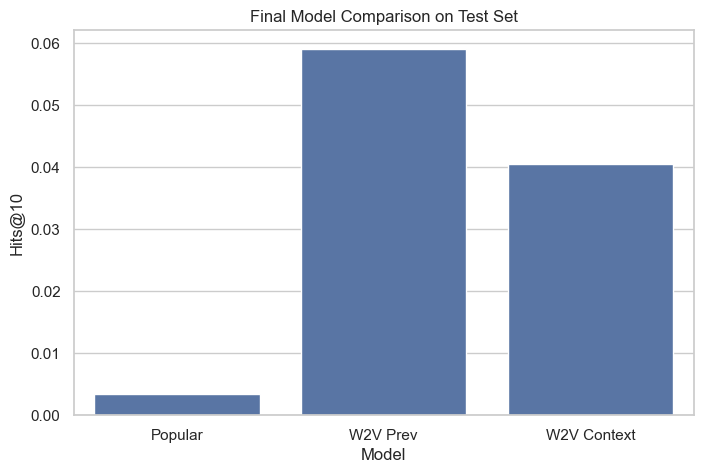

In [57]:
# Plot final model performance comparison (Hits@10)

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Hits@10")
plt.title("Final Model Comparison on Test Set")
plt.xlabel("Model")
plt.ylabel("Hits@10")
plt.show()

In [58]:
# Select final model and report official test result

eval_scores = {
    "prev": prev_eval_hit10,
    "context": context_eval_hit10
}

best_method = max(eval_scores, key=eval_scores.get)

print("=== VALIDATION RESULTS ===")
print(f"Prev Eval Hits@10: {prev_eval_hit10:.4f}")
print(f"Context Eval Hits@10: {context_eval_hit10:.4f}")
print(f"Chosen best method from eval: {best_method}")

print("\n=== TEST RESULTS ===")
print(f"Final Prev Test Hits@10: {prev_test_hit10:.4f}")
print(f"Final Context Test Hits@10: {context_test_hit10:.4f}")

if best_method == "prev":
    final_test_hit10 = prev_test_hit10
else:
    final_test_hit10 = context_test_hit10

print(f"\nOFFICIAL FINAL TEST Hits@10 ({best_method}): {final_test_hit10:.4f}")

=== VALIDATION RESULTS ===
Prev Eval Hits@10: 0.0073
Context Eval Hits@10: 0.0054
Chosen best method from eval: prev

=== TEST RESULTS ===
Final Prev Test Hits@10: 0.0592
Final Context Test Hits@10: 0.0405

OFFICIAL FINAL TEST Hits@10 (prev): 0.0592
